# Step 0: Tải các thư viện cần thiết cho bài báo cáo

In [2]:
!pip install underthesea
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 21.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1


In [ ]:
!pip install --upgrade pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 59.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


# Step 1: Dependencies import

In [1]:
import pandas as pd
import numpy as np
import string
import random
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

from underthesea import word_tokenize

from gensim.models.doc2vec import Doc2Vec, TaggedDocument

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


# Step 2: Data synthesis


In [ ]:
!pip install requests beautifulsoup4 pandas

In [37]:
!pip install feedparser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 3.1 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=9c472105119bc658633a8185d366cbe51e118c3220fc5ac4aef7e216e85d0312
  Stored in directory: /root/.cache/pip/wheels/3b/25/2a/105d6a15df6914f4d15047691c6c28f9052cc1173e40285d03
Successfully built sgmllib3k


In [50]:
import requests
from bs4 import BeautifulSoup
import csv
from tqdm import tqdm
import time

def crawl_category(category_url, label, max_pages=10):
    category_data = []
    print(f"\n🔍 Đang cào chuyên mục: {label}")
    pbar = tqdm(total=max_pages, desc=f"{label}: ", ncols=100)

    for page in range(1, max_pages + 1):
        url = f"{category_url}?page={page}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')

        articles = soup.find_all('h3', class_='title-news')

        if not articles:
            print(f"⛔ Không có bài ở trang {page}")
        else:
            for article in articles:
                link = article.find('a')
                if link and link['href']:
                    article_url = link['href']
                    try:
                        article_res = requests.get(article_url)
                        article_soup = BeautifulSoup(article_res.text, 'html.parser')
                        content = article_soup.find('article')
                        if content:
                            content_text = content.get_text(strip=True)
                            if content_text:  # Không kiểm tra độ dài
                                category_data.append({'text': content_text, 'label': label})
                                print(f"✅ Đã lấy: {article_url}")
                            else:
                                print(f"⚠️ Bỏ bài (rỗng): {article_url}")
                    except Exception as e:
                        print(f"❌ Lỗi khi lấy bài: {article_url} ({e})")

        pbar.update(1)
        time.sleep(0.2)  # nghỉ nhẹ để tránh bị chặn

    pbar.close()
    print(f"💾 Đã lưu tạm {len(category_data)} bài ở 'temp_{label}.csv'")
    return category_data

def save_to_csv(data, filename):
    with open(filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['text', 'label'])
        writer.writeheader()
        writer.writerows(data)

# Ví dụ sử dụng:
categories = {
    'v-league': 'https://vnexpress.net/bong-da/v-league',
    'premier-league': 'https://vnexpress.net/the-thao/ngoai-hang-anh',
    'champions-league': 'https://vnexpress.net/bong-da/champions-league',
    'la-liga': 'https://vnexpress.net/bong-da/tay-ban-nha',
    'serie-a': 'https://vnexpress.net/bong-da/italia',
    'bundesliga': 'https://vnexpress.net/the-thao/bundesliga',
}


all_data = []
for label, url in categories.items():
    data = crawl_category(url, label, max_pages=5)
    save_to_csv(data, f"temp_{label}.csv")
    all_data.extend(data)

# Nếu muốn lưu toàn bộ thành một file:
save_to_csv(all_data, "all_articles.csv")
print("✅ Đã lưu toàn bộ bài viết vào 'all_articles.csv'")



🔍 Đang cào chuyên mục: v-league



v-league:   0%|                                                               | 0/5 [00:00<?, ?it/s]

✅ Đã lấy: https://vnexpress.net/cau-thu-the-cong-ghi-sieu-pham-tu-san-nha-o-v-league-4870810.html
✅ Đã lấy: https://vnexpress.net/cau-thu-ha-tinh-va-binh-dinh-bop-co-nhau-4870801.html
✅ Đã lấy: https://vnexpress.net/nguyen-van-toan-lan-dau-ghi-cu-dup-cho-nam-dinh-4870797.html
✅ Đã lấy: https://vnexpress.net/binh-duong-tham-bai-truoc-hagl-4870786.html
✅ Đã lấy: https://vnexpress.net/v-league-lan-dau-co-trong-tai-var-nguoi-nuoc-ngoai-4869080.html
✅ Đã lấy: https://vnexpress.net/nam-dinh-chia-tay-doi-tac-an-y-cua-nguyen-xuan-son-4868197.html
✅ Đã lấy: https://vnexpress.net/chu-tich-clb-thanh-hoa-ap-luc-khi-chia-tay-hlv-popov-4865184.html
✅ Đã lấy: https://vnexpress.net/them-3-viet-kieu-ve-thi-dau-v-league-4860886.html
✅ Đã lấy: https://vnexpress.net/hagl-roi-chien-thang-o-phut-100-4858792.html
✅ Đã lấy: https://vnexpress.net/quang-hai-giup-cong-an-ha-noi-hoa-nam-dinh-4858548.html
✅ Đã lấy: https://vnexpress.net/tien-dao-tien-linh-chan-thuong-4858550.html
✅ Đã lấy: https://vnexpress.net/hl


v-league:  20%|███████████                                            | 1/5 [00:26<01:47, 26.94s/it]

✅ Đã lấy: https://vnexpress.net/quang-nam-muon-tuyet-giao-voi-mot-trong-tai-v-league-4851877.html


...

⛔ Không có bài ở trang 4



bundesliga: 100%|█████████████████████████████████████████████████████| 5/5 [01:17<00:00,  7.91s/it]

⛔ Không có bài ở trang 5


bundesliga: 100%|█████████████████████████████████████████████████████| 5/5 [01:18<00:00, 15.63s/it]

💾 Đã lưu tạm 30 bài ở 'temp_bundesliga.csv'
✅ Đã lưu toàn bộ bài viết vào 'all_articles.csv'


# Step 2.5: Đánh giá dataset và các thuộc tính đặc trưng bên trong



Sample Data:
                                                 text     label
0  Phút 72, khi Thể Công bị dẫn 1-2, Hữu Thắng nh...  v-league
1  Phút 49, trận đấu trên sân Quy Nhơn, khi Bình ...  v-league
2  Phút 43, Nam Định pressing ngay gần vòng cấm H...  v-league
3  Trước trận đấu trên sân Pleiku chiều nay, chiế...  v-league
4  Hai trọng tài FIFA được thuê là Mohamad Kamil ...  v-league

Missing Values:
 text     0
label    0
dtype: int64


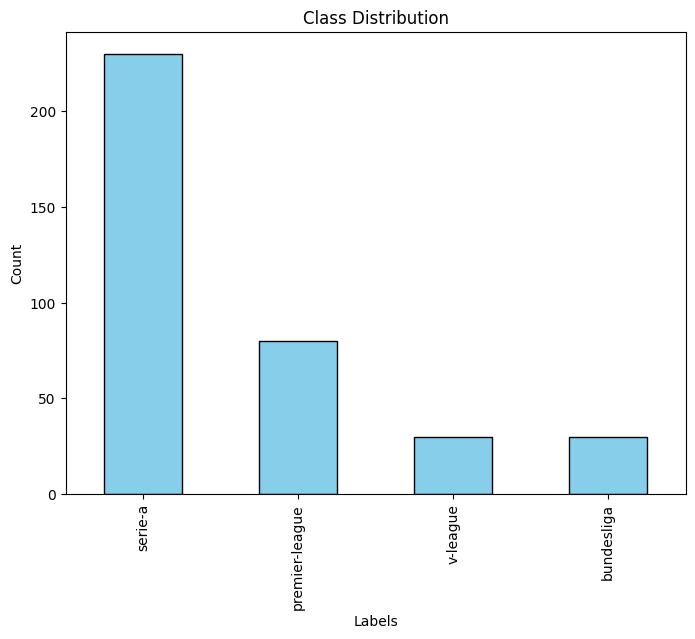

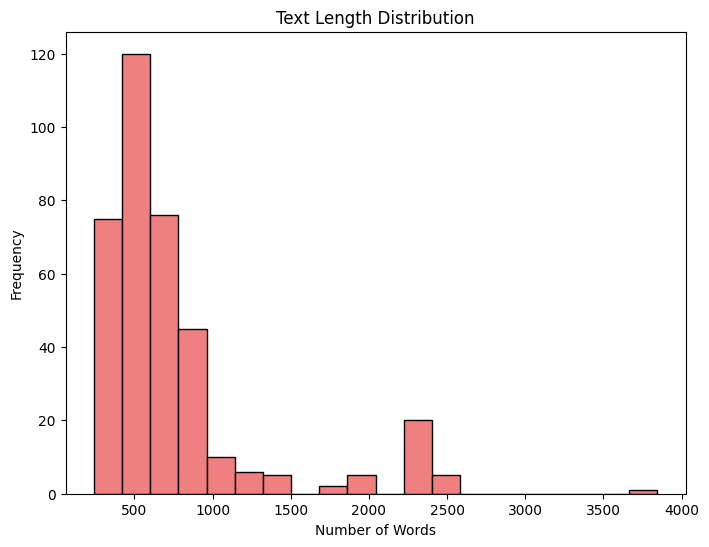


Most common words: [('và', 3944), ('của', 2577), ('là', 2449), ('trong', 2354), ('ở', 2340), ('trận', 2138), ('với', 2015), ('khi', 1935), ('có', 1833), ('không', 1826)]
Lexical Diversity: 0.0320


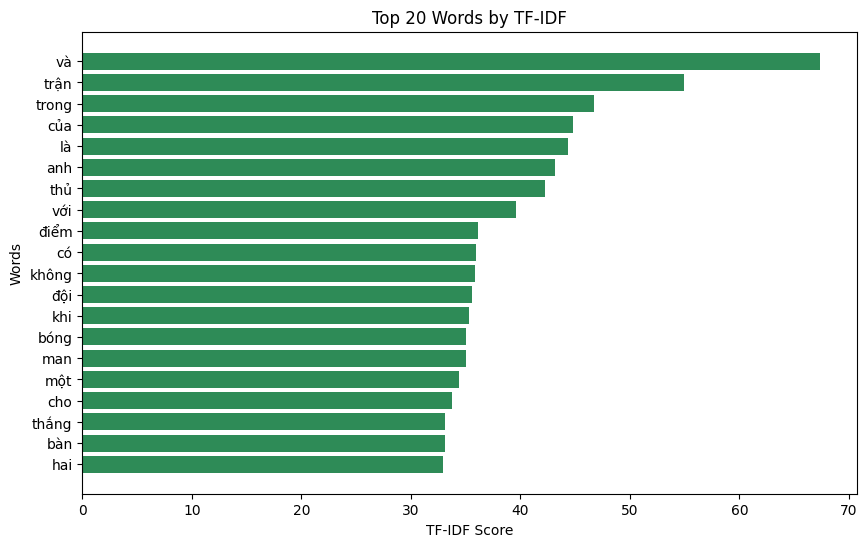

In [51]:
def load_data(file_path):
    df = pd.read_csv(file_path)
    print("\nSample Data:\n", df.head())
    return df

def check_missing_duplicates(df):
    print("\nMissing Values:\n", df.isnull().sum())

def plot_class_distribution(df):
    plt.figure(figsize=(8, 6))
    df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Class Distribution")
    plt.xlabel("Labels")
    plt.ylabel("Count")
    plt.savefig("class_distribution.png")
    plt.show()

def plot_text_length_distribution(df):
    df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(8, 6))
    plt.hist(df['text_length'], bins=20, color='lightcoral', edgecolor='black')
    plt.title("Text Length Distribution")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.savefig("text_length_distribution.png")
    plt.show()

def check_word_frequency(df):
    all_words = " ".join(df['text']).split()
    word_freq = Counter(all_words)
    print("\nMost common words:", word_freq.most_common(10))

    unique_words = len(set(all_words))
    total_words = len(all_words)
    print(f"Lexical Diversity: {unique_words / total_words:.4f}")

def plot_top_tfidf_words(df):
    vectorizer = TfidfVectorizer(max_features=100)
    X_tfidf = vectorizer.fit_transform(df['text'].astype(str))

    tfidf_words = vectorizer.get_feature_names_out()
    tfidf_values = X_tfidf.toarray().sum(axis=0)

    sorted_indices = tfidf_values.argsort()[::-1][:20]
    top_words = tfidf_words[sorted_indices]
    top_values = tfidf_values[sorted_indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_words[::-1], top_values[::-1], color='seagreen')
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Words")
    plt.title("Top 20 Words by TF-IDF")
    plt.savefig("tfidf_top_words.png")
    plt.show()

def main():
    # file_path = "/content/sample_data/vnexpress_bongda_labeled.csv"
    file_path = "all_articles.csv"
    df = load_data(file_path)
    check_missing_duplicates(df)
    plot_class_distribution(df)
    plot_text_length_distribution(df)
    check_word_frequency(df)
    plot_top_tfidf_words(df)

if __name__ == "__main__":
    main()


# Step 3: Data preprocessing and representation

In [29]:
# df = pd.read_csv("/content/sample_data/vnexpress_bongda_labeled.csv")
df = pd.read_csv("all_articles.csv")


# Text Processing Class
class TextProcessor:
    def __init__(self, df):
        self.df = df.copy()
        self.clean_text()
        self.y = self.df["label"].astype(str)

    def clean_text(self):
        self.df["clean_text"] = self.df["text"].str.lower()
        self.df["clean_text"] = self.df["clean_text"].str.replace(r"[{}]".format(string.punctuation), "", regex=True)
        self.df["clean_text"] = self.df["clean_text"].str.replace(r"\d+", "", regex=True)
        self.df["clean_text"] = self.df["clean_text"].apply(lambda x: " ".join(word_tokenize(str(x))))  # ✅ Fix: Use only underthesea

    def tfidf_vectorizer(self, X_train, X_test, max_features=100):
        vectorizer = TfidfVectorizer(max_features=max_features)
        return vectorizer.fit_transform(X_train), vectorizer.transform(X_test)

    def bag_of_words_vectorizer(self, X_train, X_test, max_features=100):
        vectorizer = CountVectorizer(max_features=max_features)
        return vectorizer.fit_transform(X_train), vectorizer.transform(X_test)

    def one_hot_encoding(self, y_train, y_test):
        encoder = OneHotEncoder(sparse_output=False)
        return encoder.fit_transform(y_train.values.reshape(-1, 1)), encoder.transform(y_test.values.reshape(-1, 1))

# Sample 80% of data
df = df.sample(frac=0.8, random_state=42)
df.reset_index(drop=True, inplace=True)

print("Dữ liệu mẫu:")
print(df.head())

processor = TextProcessor(df)  # Original processor for full dataset

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

# Create Processors for Train & Test
processor_train = TextProcessor(pd.DataFrame({"text": X_train_raw, "label": y_train}))
processor_test = TextProcessor(pd.DataFrame({"text": X_test_raw, "label": y_test}))

X_train, X_test = processor_train.df["clean_text"], processor_test.df["clean_text"]

# Vectorization
X_tfidf_train, X_tfidf_test = processor_train.tfidf_vectorizer(X_train, X_test)
X_bow_train, X_bow_test = processor_train.bag_of_words_vectorizer(X_train, X_test)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# One-Hot Encoding
X_one_hot_train, X_one_hot_test = processor_train.one_hot_encoding(y_train, y_test)

# Shape Summary
print("TF-IDF Shape:", X_tfidf_train.shape)
print("BoW Shape:", X_bow_train.shape)
print("One-Hot Shape:", X_one_hot_train.shape)


Dữ liệu mẫu:
                                                text           label
0  Trận hòa tại Old Trafford ngày 6/4 khiến Man C...  Premier League
1  Đây là lần đầu kể từ năm 2006, Arsenal đụng Re...         Serie A
2  Sau 12 trận liên tiếp phân thắng bại, derby Ma...         Serie A
3  Trong hiệp một trận derby Manchester ngày 6/4,...         Serie A
4  Nam Định vừa dừng bước ở vòng 1/8 AFC Champion...        V-League
TF-IDF Shape: (21, 100)
BoW Shape: (21, 100)
One-Hot Shape: (21, 3)


# Step 4: Lựa chọn model, training và đánh giá dựa trên các phương thức vector hóa câu từ



Using Bag of Words representation:

Model: Logistic Regression
Accuracy: 0.5
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.33      0.50         3
           2       0.40      1.00      0.57         2

    accuracy                           0.50         6
   macro avg       0.47      0.44      0.36         6
weighted avg       0.63      0.50      0.44         6


Model: Naïve Bayes
Accuracy: 0.6666666666666666
Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.33      0.50         3
           2       0.67      1.00      0.80         2

    accuracy                           0.67         6
   macro avg       0.72      0.78      0.66         6
weighted avg       0.81      0.67      0.63         6


Model: Decision Tree
Accuracy: 0.8333333333333334
Classification

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

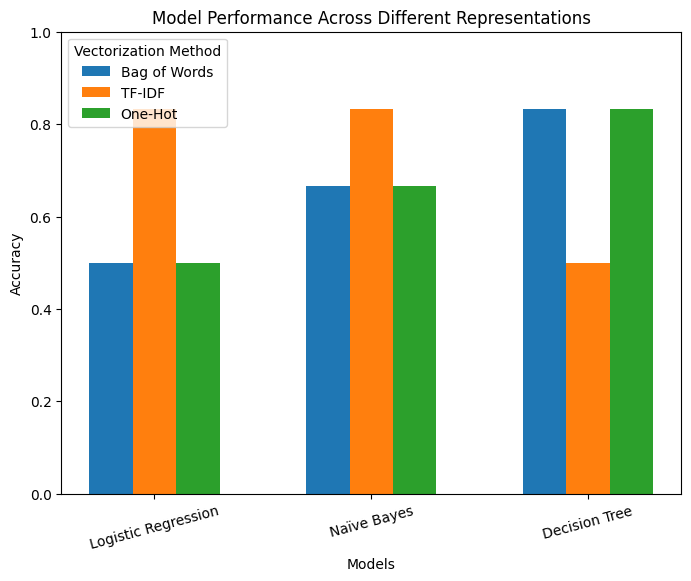

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naïve Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

vectorizers = {
    "Bag of Words": (X_bow_train, X_bow_test),
    "TF-IDF": (X_tfidf_train, X_tfidf_test),
    "One-Hot": (X_one_hot_train, X_one_hot_test)
}

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Store accuracy results
accuracy_results = {}

for vec_name, (X_train_enc, X_test_enc) in vectorizers.items():
    print(f"\nUsing {vec_name} representation:")
    accuracy_results[vec_name] = {}

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")

        # Ensure labels are in the correct format
        if vec_name == "One-Hot":
            X_train_enc, X_test_enc = processor.bag_of_words_vectorizer(X_train, X_test)
            y_train_enc, y_test_enc = y_train_encoded, y_test_encoded  # Use LabelEncoder()
        else:
            y_train_enc, y_test_enc = y_train_encoded, y_test_encoded  # Ensure labels are encoded


        model.fit(X_train_enc, y_train_enc)
        y_pred = model.predict(X_test_enc)

        acc = accuracy_score(y_test_enc, y_pred)
        accuracy_results[vec_name][model_name] = acc  # Store accuracy

        print("Accuracy:", acc)
        print("Classification Report:")
        print(classification_report(y_test_enc, y_pred))

# Plot accuracy results
fig, ax = plt.subplots(figsize=(8, 6))
bar_width = 0.2
index = np.arange(len(models))

for i, (vec_name, acc_dict) in enumerate(accuracy_results.items()):
    accuracies = [acc_dict[m] for m in models.keys()]
    ax.bar(index + i * bar_width, accuracies, bar_width, label=vec_name)

ax.set_xlabel("Models")
ax.set_ylabel("Accuracy")
ax.set_title("Model Performance Across Different Representations")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(models.keys(), rotation=15)
ax.legend(title="Vectorization Method")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.show()

# Step 5: Doc2Vec


In [31]:
# Load dataset
df = pd.read_csv("/content/sample_data/vnexpress_bongda_labeled.csv")

# Preprocess text data
df["text"] = df["text"].str.lower().str.replace(r"[^a-zA-Z0-9 ]", "", regex=True)

# Encode labels
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label_encoded"], test_size=0.2, random_state=42)

# --- Gensim Doc2Vec ---
train_corpus = [TaggedDocument(words=text.split(), tags=[i]) for i, text in enumerate(X_train)]
test_corpus = [text.split() for text in X_test]

gensim_model = Doc2Vec(vector_size=50, window=5, min_count=2, workers=4, epochs=10)
gensim_model.build_vocab(train_corpus)
gensim_model.train(train_corpus, total_examples=gensim_model.corpus_count, epochs=gensim_model.epochs)

X_train_gensim = [gensim_model.infer_vector(doc.words) for doc in train_corpus]
X_test_gensim = [gensim_model.infer_vector(doc) for doc in test_corpus]

# --- Custom PyTorch Doc2Vec ---
class Doc2VecDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [[vocab.get(w, 0) for w in text.split()] for text in texts]
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

vocab = {word: i+1 for i, word in enumerate(set(" ".join(X_train).split()))}
vocab["<PAD>"] = 0

train_dataset = Doc2VecDataset(X_train, y_train.tolist(), vocab)
test_dataset = Doc2VecDataset(X_test, y_test.tolist(), vocab)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)




In [32]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts  # Already tokenized sequences
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx], dtype=torch.long), self.labels[idx]

# Custom collate function for dynamic padding
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0).to(device)  # Apply padding
    labels = torch.tensor(labels, dtype=torch.long).to(device)
    return texts_padded, labels

# Define PyTorch Doc2Vec Model
class SimpleDoc2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SimpleDoc2Vec, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc = nn.Linear(embedding_dim, 50)
        self.bn = nn.BatchNorm1d(50)  # Normalize embeddings for better stability

    def forward(self, x):
        embedded = self.embedding(x)  # Shape: (batch, seq_len, embedding_dim)
        x = embedded.mean(dim=1)  # Average over the sequence length
        x = self.bn(self.fc(x))  # Apply batch normalization
        return x

# Model setup
embedding_dim = 50
vocab_size = len(vocab) + 1  # +1 for padding index
model = SimpleDoc2Vec(vocab_size, embedding_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Training function
def train_model(num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for texts, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}")

# Train the model
train_model(num_epochs=5)

# Function to extract document vectors
def get_pytorch_vectors(dataloader):
    model.eval()
    vectors = []
    with torch.no_grad():
        for texts, _ in dataloader:
            outputs = model(texts)  # Get doc vectors
            vectors.append(outputs.cpu().numpy())  # Ensure conversion from GPU to CPU
    return np.vstack(vectors)

# Extract vectors
X_train_torch = get_pytorch_vectors(train_loader)
X_test_torch = get_pytorch_vectors(test_loader)


Epoch 1/5, Loss: 4.6550
Epoch 2/5, Loss: 4.5970
Epoch 3/5, Loss: 4.5401
Epoch 4/5, Loss: 4.4845
Epoch 5/5, Loss: 4.4303


In [33]:
# --- Classifier Evaluation ---
clf_gensim = LogisticRegression(max_iter=500).fit(X_train_gensim, y_train)
y_pred_gensim = clf_gensim.predict(X_test_gensim)
acc_gensim = accuracy_score(y_test, y_pred_gensim)

clf_torch = LogisticRegression(max_iter=10000).fit(X_train_torch, y_train)
y_pred_torch = clf_torch.predict(X_test_torch)
acc_torch = accuracy_score(y_test, y_pred_torch)

print(f"Gensim Doc2Vec Accuracy: {acc_gensim:.4f}")
print(f"PyTorch Doc2Vec Accuracy: {acc_torch:.4f}")

Gensim Doc2Vec Accuracy: 0.8571
PyTorch Doc2Vec Accuracy: 0.7143
